In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/aac_intakes_outcomes.csv")

df.head()

,age_upon_outcome,animal_id_outcome,date_of_birth,outcome_subtype,outcome_type,sex_upon_outcome,age_upon_outcome_(days),age_upon_outcome_(years),age_upon_outcome_age_group,outcome_datetime,...,age_upon_intake_age_group,intake_datetime,intake_month,intake_year,intake_monthyear,intake_weekday,intake_hour,intake_number,time_in_shelter,time_in_shelter_days
0,10 years,A006100,2007-07-09 00:00:00,NaN,Return to Owner,Neutered Male,3650,10.0,"(7.5, 10.0]",2017-12-07 14:07:00,...,"(7.5, 10.0]",2017-12-07 00:00:00,12,2017,2017-12,Thursday,14,1.0,0 days 14:07:00.000000000,0.588194
1,7 years,A006100,2007-07-09 00:00:00,NaN,Return to Owner,Neutered Male,2555,7.0,"(5.0, 7.5]",2014-12-20 16:35:00,...,"(5.0, 7.5]",2014-12-19 10:21:00,12,2014,2014-12,Friday,10,2.0,1 days 06:14:00.000000000,1.259722
2,6 years,A006100,2007-07-09 00:00:00,NaN,Return to Owner,Neutered Male,2190,6.0,"(5.0, 7.5]",2014-03-08 17:10:00,...,"(5.0, 7.5]",2014-03-07 14:26:00,3,2014,2014-03,Friday,14,3.0,1 days 02:44:00.000000000,1.113889
3,10 years,A047759,2004-04-02 00:00:00,Partner,Transfer,Neutered Male,3650,10.0,"(7.5, 10.0]",2014-04-07 15:12:00,...,"(7.5, 10.0]",2014-04-02 15:55:00,4,2014,2014-04,Wednesday,15,1.0,4 days 23:17:00.000000000,4.970139
4,16 years,A134067,1997-10-16 00:00:00,NaN,Return to Owner,Neutered Male,5840,16.0,"(15.0, 17.5]",2013-11-16 11:54:00,...,"(15.0, 17.5]",2013-11-16 09:02:00,11,2013,2013-11,Saturday,9,1.0,0 days 02:52:00.000000000,0.119444


In [2]:
df.shape

(79672, 41)

In [3]:
df.columns

Index(['age_upon_outcome', 'animal_id_outcome', 'date_of_birth',
       'outcome_subtype', 'outcome_type', 'sex_upon_outcome',
       'age_upon_outcome_(days)', 'age_upon_outcome_(years)',
       'age_upon_outcome_age_group', 'outcome_datetime', 'outcome_month',
       'outcome_year', 'outcome_monthyear', 'outcome_weekday', 'outcome_hour',
       'outcome_number', 'dob_year', 'dob_month', 'dob_monthyear',
       'age_upon_intake', 'animal_id_intake', 'animal_type', 'breed', 'color',
       'found_location', 'intake_condition', 'intake_type', 'sex_upon_intake',
       'count', 'age_upon_intake_(days)', 'age_upon_intake_(years)',
       'age_upon_intake_age_group', 'intake_datetime', 'intake_month',
       'intake_year', 'intake_monthyear', 'intake_weekday', 'intake_hour',
       'intake_number', 'time_in_shelter', 'time_in_shelter_days'],
      dtype='str')

In [4]:
df_adopted = df[df["outcome_type"] == "Adoption"]

df_adopted.shape


(33594, 41)

In [5]:
df_adopted["time_in_shelter_days"].describe()

count    33594.000000
mean        29.460366
std         52.144263
min          0.000694
25%          4.961806
50%         10.225000
75%         36.210417
max       1268.975000
Name: time_in_shelter_days, dtype: float64

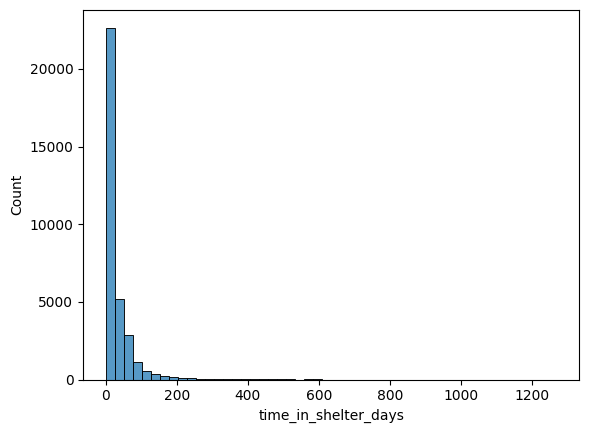

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_adopted["time_in_shelter_days"], bins=50)
plt.show()

In [7]:
df_adopted["animal_type"].value_counts()


animal_type
Dog      20581
Cat      12675
Other      223
Bird       115
Name: count, dtype: int64

In [8]:
df_model = df_adopted[df_adopted["animal_type"].isin(["Dog", "Cat"])]

df_model.shape

(33256, 41)

In [9]:
df_model["breed"].value_counts().head(10)

breed
Domestic Shorthair Mix       9865
Labrador Retriever Mix       2368
Pit Bull Mix                 2324
Chihuahua Shorthair Mix      2270
Domestic Medium Hair Mix     1037
German Shepherd Mix           922
Australian Cattle Dog Mix     607
Domestic Longhair Mix         578
Siamese Mix                   455
Dachshund Mix                 390
Name: count, dtype: int64

In [10]:
df_model.groupby("animal_type")["time_in_shelter_days"].median()

animal_type
Cat    24.206250
Dog     7.116667
Name: time_in_shelter_days, dtype: float64

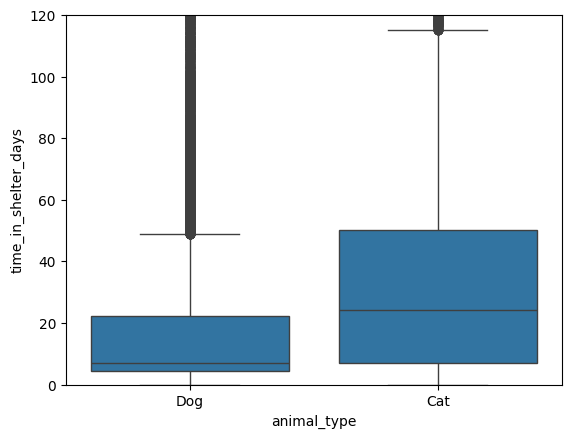

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df_model, x="animal_type", y="time_in_shelter_days")
plt.ylim(0, 120)
plt.show()

In [1]:
import pandas as pd
df = pd.read_csv("../data/raw/aac_intakes_outcomes.csv")
df_adopted = df[df["outcome_type"] == "Adoption"]
df_model = df_adopted[df_adopted["animal_type"].isin(["Dog", "Cat"])]

In [2]:
feature_cols = [
    "animal_type",
    "breed",
    "color",
    "intake_type",
    "intake_condition",
    "sex_upon_intake",
    "age_upon_intake_(years)",
    "age_upon_intake_age_group",
    "intake_month",
    "intake_weekday",
    "intake_hour",
    "time_in_shelter_days"
]

df_features = df_model[feature_cols].copy()

df_features.isna().sum()

animal_type                  0
breed                        0
color                        0
intake_type                  0
intake_condition             0
sex_upon_intake              0
age_upon_intake_(years)      0
age_upon_intake_age_group    0
intake_month                 0
intake_weekday               0
intake_hour                  0
time_in_shelter_days         0
dtype: int64

In [3]:
df_features["primary_breed"] = df_features["breed"].str.split(" ").str[0]

df_features["primary_breed"].value_counts().head(10)

primary_breed
Domestic      11754
Labrador       3095
Chihuahua      2945
Pit            2516
Australian     1268
German         1256
Miniature       716
Border          596
Dachshund       567
Siamese         486
Name: count, dtype: int64

In [4]:
df_features["sex_upon_intake"].value_counts()

sex_upon_intake
Intact Male      12278
Intact Female    12047
Spayed Female     4525
Neutered Male     4405
Unknown              1
Name: count, dtype: int64

In [5]:
df_features["sex"] = df_features["sex_upon_intake"].str.contains("Male").map({True: "Male", False: "Female"})

In [6]:
df_features["sex"].value_counts()

sex
Male      16683
Female    16573
Name: count, dtype: int64

In [7]:
df_features = df_features.rename(columns={
    "age_upon_intake_(years)": "age_years"
})

df_features.head()

,animal_type,breed,color,intake_type,intake_condition,sex_upon_intake,age_years,age_upon_intake_age_group,intake_month,intake_weekday,intake_hour,time_in_shelter_days,primary_breed,sex
12,Dog,Dachshund Mix,Black/Tan,Owner Surrender,Normal,Neutered Male,16.0,"(15.0, 17.5]",10,Thursday,15,49.747917,Dachshund,Male
14,Dog,Chihuahua Shorthair,Tan/Black,Public Assist,Aged,Neutered Male,17.0,"(15.0, 17.5]",9,Wednesday,12,9.020139,Chihuahua,Male
22,Dog,Labrador Retriever/Beagle,Sable/White,Stray,Normal,Neutered Male,15.0,"(12.5, 15.0]",10,Tuesday,12,23.104861,Labrador,Male
32,Dog,German Shepherd Mix,Black/Brown,Stray,Normal,Spayed Female,15.0,"(12.5, 15.0]",8,Wednesday,14,89.855556,German,Female
48,Dog,Pointer Mix,Tricolor,Stray,Normal,Spayed Female,11.0,"(10.0, 12.5]",11,Wednesday,18,2.755556,Pointer,Female


In [8]:
df_features = df_features.drop(columns=[
    "breed",
    "sex_upon_intake",
    "age_upon_intake_age_group"
])

df_features.columns

Index(['animal_type', 'color', 'intake_type', 'intake_condition', 'age_years',
       'intake_month', 'intake_weekday', 'intake_hour', 'time_in_shelter_days',
       'primary_breed', 'sex'],
      dtype='str')

In [9]:
df_features.dtypes

animal_type                 str
color                       str
intake_type                 str
intake_condition            str
age_years               float64
intake_month              int64
intake_weekday              str
intake_hour               int64
time_in_shelter_days    float64
primary_breed            object
sex                         str
dtype: object

In [10]:
df_encoded = pd.get_dummies(
    df_features,
    columns=[
        "animal_type",
        "color",
        "intake_type",
        "intake_condition",
        "intake_weekday",
        "primary_breed",
        "sex"
    ],
    drop_first=True
)

df_encoded.head()

,age_years,intake_month,intake_hour,time_in_shelter_days,animal_type_Dog,color_Agouti/Brown Tabby,color_Apricot,color_Apricot/White,color_Black,color_Black Brindle,...,primary_breed_Whippet/Borzoi,primary_breed_Whippet/Chihuahua,primary_breed_Whippet/Dachshund,primary_breed_Whippet/Jack,primary_breed_Whippet/Labrador,primary_breed_Whippet/Shetland,primary_breed_Wire,primary_breed_Wirehaired,primary_breed_Yorkshire,sex_Male
12,16.0,10,15,49.747917,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
14,17.0,9,12,9.020139,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
22,15.0,10,12,23.104861,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
32,15.0,8,14,89.855556,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
48,11.0,11,18,2.755556,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [11]:
df_encoded.shape

(33256, 807)

In [12]:
X = df_encoded.drop(columns=["time_in_shelter_days"])
y = df_encoded["time_in_shelter_days"]

X.shape, y.shape

((33256, 806), (33256,))

In [13]:
df_encoded = pd.get_dummies(
    df_features,
    columns=[
        "animal_type",
        "intake_type",
        "intake_condition",
        "intake_weekday",
        "primary_breed",
        "sex"
    ],
    drop_first=True
)

df_encoded.shape

(33256, 439)

In [14]:
X = df_encoded.drop(columns=["time_in_shelter_days"])
y = df_encoded["time_in_shelter_days"]

X.shape

(33256, 438)